In [1]:
import sys
print(sys.executable)

C:\Users\Client\VolCast\.venv\Scripts\python.exe


## Phase 1 — Données, rendements et cible de volatilité 

In [2]:
import yfinance as yf
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
import torch 
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_absolute_error, mean_squared_error
import scipy.stats as stats

In [3]:
df = yf.download("^GSPC", start="2000-01-01", auto_adjust=True)
prices = df["Close"].squeeze()
print(prices.head())
print(prices.tail())
print(len(prices))

[*********************100%***********************]  1 of 1 completed

Date
2000-01-03    1455.219971
2000-01-04    1399.420044
2000-01-05    1402.109985
2000-01-06    1403.449951
2000-01-07    1441.469971
Name: ^GSPC, dtype: float64
Date
2026-09-30    7651.540039
2026-10-01    7666.450195
2026-10-02    7722.720215
2026-10-05    7773.950195
2026-10-06    7818.930176
Name: ^GSPC, dtype: float64
6730


In [4]:
#calcul des rendements logarithmique  
log_returns =  np.log(prices/prices.shift(1)).dropna()
#verification
print(log_returns.head())


Date
2000-01-04   -0.039099
2000-01-05    0.001920
2000-01-06    0.000955
2000-01-07    0.026730
2000-01-10    0.011128
Name: ^GSPC, dtype: float64


In [5]:
volatility_5d = log_returns.rolling(window=5).std()
print("les 8 premiéres valeurs de la volatilité:")
print(volatility_5d.head(8))
print (f"\nNombre de NaN générés : {volatility_5d.isna().sum()}")

les 8 premiéres valeurs de la volatilité:
Date
2000-01-04         NaN
2000-01-05         NaN
2000-01-06         NaN
2000-01-07         NaN
2000-01-10    0.024347
2000-01-11    0.014694
2000-01-12    0.015338
2000-01-13    0.015546
Name: ^GSPC, dtype: float64

Nombre de NaN générés : 4


In [6]:
target = volatility_5d.shift(-5)
target.name = "Target_Feature_Vol_5d"

print("Les 8 derniéres lignes de la cible ( target):")
print(target.tail(8))

Les 8 derniéres lignes de la cible ( target):
Date
2026-09-25    0.005589
2026-09-28    0.004551
2026-09-29    0.004108
2026-09-30         NaN
2026-10-01         NaN
2026-10-02         NaN
2026-10-05         NaN
2026-10-06         NaN
Name: Target_Feature_Vol_5d, dtype: float64


In [7]:
df_model = pd.DataFrame({
    'Log-Return' : log_returns,
    'Vol_Past_5d' : volatility_5d,
    'Target_Vol_Future_5d' : target
})
df_clean = df_model.dropna()

print("Nombre de lignes initiales (prix) :",len(prices))
print("Nombre de ligne finales (dataset propre):", len(df_clean))
print("\n 5 premiéres lignes ")
print(df_clean.head())
print("\n 5 derniéres lignes ")
print(df_clean.tail())

Nombre de lignes initiales (prix) : 6730
Nombre de ligne finales (dataset propre): 6720

 5 premiéres lignes 
            Log-Return  Vol_Past_5d  Target_Vol_Future_5d
Date                                                     
2000-01-10    0.011128     0.024347              0.011154
2000-01-11   -0.013149     0.014694              0.008615
2000-01-12   -0.004396     0.015338              0.009217
2000-01-13    0.012096     0.015546              0.007289
2000-01-14    0.010615     0.011423              0.011153

 5 derniéres lignes 
            Log-Return  Vol_Past_5d  Target_Vol_Future_5d
Date                                                     
2026-09-23   -0.007577     0.009029              0.004608
2026-09-24   -0.000247     0.008137              0.004846
2026-09-25    0.005086     0.008272              0.005589
2026-09-28   -0.007742     0.005506              0.004551
2026-09-29   -0.001674     0.005398              0.004108


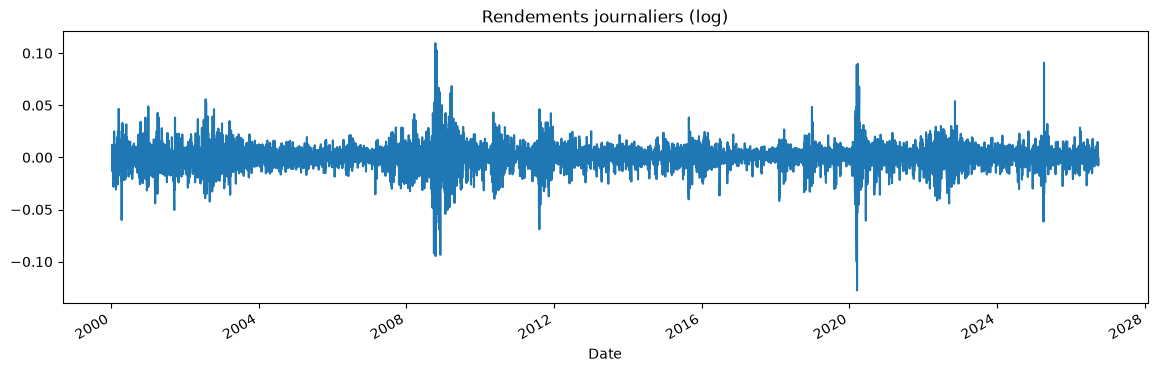

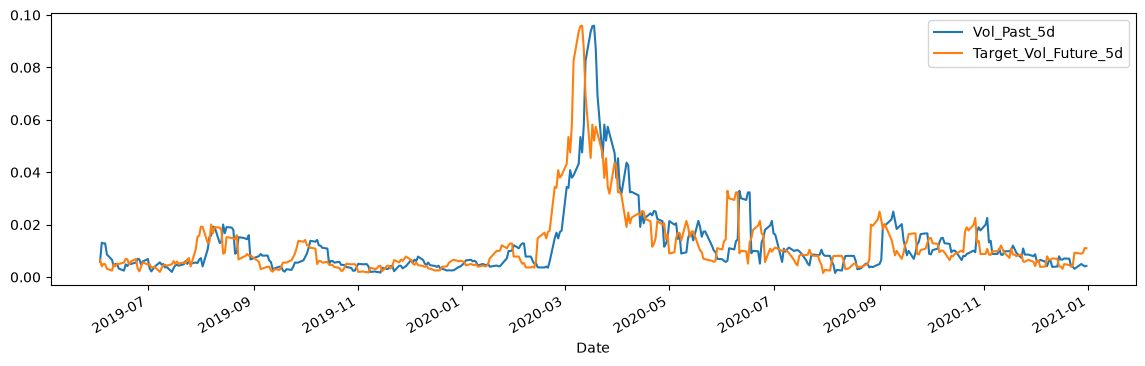

Corrélation past_vol → target : 0.6650
Corrélation log → target      : -0.1568


In [8]:
df_clean["Log-Return"].plot(figsize=(14,4), title="Rendements journaliers (log)")
plt.show()
df_clean.loc["2019-06":"2020-12",["Vol_Past_5d","Target_Vol_Future_5d"]].plot(figsize=(14,4))
plt.show()
corr_vol = df_clean["Vol_Past_5d"].corr(df_clean["Target_Vol_Future_5d"])
corr_log = df_clean["Log-Return"].corr(df_clean["Target_Vol_Future_5d"])
print(f"Corrélation past_vol → target : {corr_vol:.4f}")
print(f"Corrélation log → target      : {corr_log:.4f}")

In [9]:
# Expérience 4 : casser volontairement le sens du décalage
target_faux = volatility_5d.shift(5)   # notez : +5 au lieu de -5
data_faux = pd.DataFrame({
    "past_vol": volatility_5d,
    "target_faux": target_faux
}).dropna()

corr_faux = data_faux["past_vol"].corr(data_faux["target_faux"])
print(f"Corrélation avec shift(+5) (erroné) : {corr_faux:.4f}")

Corrélation avec shift(+5) (erroné) : 0.6650


 ## PHASE 2 - Baseline naive et GARCH

In [10]:
mae = (df_clean["Vol_Past_5d"] - df_clean["Target_Vol_Future_5d"]).abs().mean()
print(f"Erreur absolue moyenne (MAE) - Baseline Naïve : {mae:.6f}")

Erreur absolue moyenne (MAE) - Baseline Naïve : 0.004173


In [11]:
# 1. Préparation des données (rendements en %)
returns_pct = df_clean["Log-Return"] * 100

# 2. Création du modèle GARCH(1,1)
# mean='Zero' : on suppose une moyenne nulle pour les rendements
#   (c'est un choix courant en modélisation de volatilité pure,
#    car la moyenne des rendements journaliers est proche de 0
#    et son estimation ajoute surtout du bruit, pas de signal utile)
model = arch_model(returns_pct, mean='Zero', vol='Garch', p=1, q=1, dist='normal')

# 3. Entraînement du modèle
res_garch = model.fit(disp='off')

# 4. Récupération de la volatilité conditionnelle estimée
# On redivise par 100 pour revenir à l'échelle décimale d'origine
df_clean["Vol_GARCH_1d"] = res_garch.conditional_volatility / 100

# PAS de sqrt(5) ici : Vol_Past_5d et Target_Vol_Future_5d sont déjà
# des écarts-types de rendements journaliers sur une fenêtre de 5 jours,
# pas des volatilités de rendement cumulé sur 5 jours.
# Vol_GARCH_1d est donc directement comparable, sans transformation.

# Affichage des 5 premières lignes du résultat
print(df_clean[["Log-Return", "Vol_Past_5d", "Vol_GARCH_1d", "Target_Vol_Future_5d"]].head())

            Log-Return  Vol_Past_5d  Vol_GARCH_1d  Target_Vol_Future_5d
Date                                                                   
2000-01-10    0.011128     0.024347      0.013181              0.011154
2000-01-11   -0.013149     0.014694      0.012926              0.008615
2000-01-12   -0.004396     0.015338      0.012923              0.009217
2000-01-13    0.012096     0.015546      0.012214              0.007289
2000-01-14    0.010615     0.011423      0.012184              0.011153


In [12]:
# MAE pour GARCH(1,1)
mae_garch = (df_clean["Vol_GARCH_1d"] - df_clean["Target_Vol_Future_5d"]).abs().mean()
print(f"Erreur absolue moyenne (MAE) - GARCH(1,1) : {mae_garch:.6f}")

# Comparaison directe avec la baseline
print(f"\nComparaison :")
print(f"Baseline naïve : {mae:.6f}")
print(f"GARCH(1,1)     : {mae_garch:.6f}")

Erreur absolue moyenne (MAE) - GARCH(1,1) : 0.003731

Comparaison :
Baseline naïve : 0.004173
GARCH(1,1)     : 0.003731


## Phase 3 - Split temporel et fenétre pour le LSTM


In [13]:
# Choisis une date de coupure — à adapter selon ta réponse
date_coupure = "2020-01-01"

train = df_clean[df_clean.index < date_coupure]
test = df_clean[df_clean.index >= date_coupure]

print(f"Train : {len(train)} lignes, du {train.index.min()} au {train.index.max()}")
print(f"Test  : {len(test)} lignes, du {test.index.min()} au {test.index.max()}")
print(f"Proportion train/test : {len(train)/len(df_clean)*100:.1f}% / {len(test)/len(df_clean)*100:.1f}%")

Train : 5026 lignes, du 2000-01-10 00:00:00 au 2019-12-31 00:00:00
Test  : 1694 lignes, du 2020-01-02 00:00:00 au 2026-09-29 00:00:00
Proportion train/test : 74.8% / 25.2%


In [14]:
def create_windows(df, feature_col, target_col, window_size=20):
    """
    Construit des fenêtres glissantes pour le LSTM.
    Chaque fenêtre = window_size jours de 'feature_col' passés
    associés à UNE valeur de 'target_col' (déjà alignée sur le futur).
    """
    features = df[feature_col].values
    targets = df[target_col].values
    
    X, y = [], []
    for i in range(window_size, len(df)):
        X.append(features[i - window_size:i])   # les 'window_size' jours précédant i
        y.append(targets[i])                     # la cible correspondant au jour i
    
    return np.array(X), np.array(y)

# IMPORTANT : on construit les fenêtres SÉPARÉMENT sur train et test,
# jamais sur df_clean en entier avant de couper — sinon des fenêtres
# chevaucheraient la frontière et mélangeraient les deux périodes.

WINDOW_SIZE = 20

X_train, y_train = create_windows(train, "Log-Return", "Target_Vol_Future_5d", WINDOW_SIZE)
X_test, y_test = create_windows(test, "Log-Return", "Target_Vol_Future_5d", WINDOW_SIZE)

print(f"X_train : {X_train.shape}  (nb_fenêtres, window_size)")
print(f"y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_test  : {y_test.shape}")

X_train : (5006, 20)  (nb_fenêtres, window_size)
y_train : (5006,)
X_test  : (1674, 20)
y_test  : (1674,)


## Phase 4 — Construction et entraînement du LSTM

In [15]:
# 1. Conversion en tenseurs PyTorch (float32, requis pour l'entraînement)
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# 2. Ajout de la 3e dimension requise par nn.LSTM : (batch, sequence_length, nb_features)
# X_train est actuellement (5006, 20) -> on veut (5006, 20, 1)
X_train_t = X_train_t.unsqueeze(-1)
X_test_t = X_test_t.unsqueeze(-1)

# y_train reste 1D pour l'instant, on l'ajustera si besoin au moment du calcul de la perte
print(f"X_train_t : {X_train_t.shape}")
print(f"y_train_t : {y_train_t.shape}")
print(f"X_test_t  : {X_test_t.shape}")
print(f"y_test_t  : {y_test_t.shape}")

X_train_t : torch.Size([5006, 20, 1])
y_train_t : torch.Size([5006])
X_test_t  : torch.Size([1674, 20, 1])
y_test_t  : torch.Size([1674])


In [16]:
class VolLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=32):
        super().__init__()
        # La couche LSTM lit la séquence temporelle de 20 jours
        # input_size=1 correspond à la 3ème dimension (1 feature : le rendement)
        # batch_first=True assure que le format attendu est (batch_size, seq_len, features)
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        
        # La couche linéaire transforme l'état caché final en une seule prédiction (la volatilité)
        self.fc = nn.Linear(in_features=hidden_size, out_features=1)
        
    def forward(self, x):
        # Passage dans le LSTM
        # out contient les sorties pour chaque pas de temps
        # h_n contient l'état caché final de la séquence
        out, (h_n, c_n) = self.lstm(x)
        
        # On isole le dernier état caché (celui qui a "vu" les 20 jours complets)
        last_hidden_state = h_n[-1]
        
        # Passage dans la couche dense pour obtenir la valeur de volatilité prédite
        prediction = self.fc(last_hidden_state)
        
        return prediction

# Test rapide pour vérifier que la classe fonctionne avec vos données
# On instancie le modèle
model = VolLSTM(input_size=1, hidden_size=32)

# On simule un passage (forward) avec le premier batch de X_train_t (ex: 64 premières fenêtres)
# Assurez-vous que X_train_t a bien été créé à l'étape 5.1 avec la forme (5006, 20, 1)
try:
    test_batch = X_train_t[:64]
    test_output = model(test_batch)
    print(f"Forme de l'entrée (batch) : {test_batch.shape}")
    print(f"Forme de la sortie (prédictions) : {test_output.shape}") 
except NameError:
    print("X_train_t n'est pas encore défini en mémoire. Exécutez d'abord l'étape 5.1.")

Forme de l'entrée (batch) : torch.Size([64, 20, 1])
Forme de la sortie (prédictions) : torch.Size([64, 1])


## Phase 6 — Surveillance de l'entraînement et analyse de la convergence (Validation & Overfitting)

In [17]:
# 1. Instanciation du modèle, de la perte (MSE) et de l'optimiseur (Adam)
model = VolLSTM(input_size=1, hidden_size=32)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 2. Paramètres d'entraînement
epochs = 50
batch_size = 64
num_samples = X_train_t.shape[0]

# Assurer que y_train_t a la forme (5006, 1) pour correspondre à la sortie du modèle
if y_train_t.dim() == 1:
    y_train_t = y_train_t.unsqueeze(-1)

# 3. Boucle d'entraînement
model.train()
print("Début de l'entraînement du LSTM...")

for epoch in range(1, epochs + 1):
    # Permutation aléatoire des indices à chaque époque
    permutation = torch.randperm(num_samples)
    epoch_loss = 0.0
    
    for i in range(0, num_samples, batch_size):
        # Découpage du mini-batch
        indices = permutation[i : i + batch_size]
        batch_x = X_train_t[indices]
        batch_y = y_train_t[indices]
        
        # A. Réinitialisation des gradients
        optimizer.zero_grad()
        
        # B. Passage avant (Forward)
        predictions = model(batch_x)
        
        # C. Calcul de l'erreur (Loss)
        loss = criterion(predictions, batch_y)
        
        # D. Rétropropagation (Backward)
        loss.backward()
        
        # E. Mise à jour des poids
        optimizer.step()
        
        # Accumulation de la perte
        epoch_loss += loss.item() * batch_x.size(0)
    
    # Perte moyenne de l'époque
    total_epoch_loss = epoch_loss / num_samples
    
    if epoch % 10 == 0 or epoch == 1:
        print(f"Époque [{epoch:2d}/{epochs}] - Loss (MSE) : {total_epoch_loss:.6f}")

# 4. Génération des prédictions sur le jeu de test (out-of-sample)
model.eval()
with torch.no_grad():
    y_pred_lstm_t = model(X_test_t)
    # Conversion en tableau 1D NumPy
    y_pred_lstm = y_pred_lstm_t.squeeze().numpy()

print("\nEntraînement terminé !")
print(f"Forme des prédictions sur X_test : {y_pred_lstm.shape}")

Début de l'entraînement du LSTM...
Époque [ 1/50] - Loss (MSE) : 0.000414
Époque [10/50] - Loss (MSE) : 0.000051
Époque [20/50] - Loss (MSE) : 0.000050
Époque [30/50] - Loss (MSE) : 0.000044
Époque [40/50] - Loss (MSE) : 0.000038
Époque [50/50] - Loss (MSE) : 0.000039

Entraînement terminé !
Forme des prédictions sur X_test : (1674,)


## Phase 7 — Évaluation comparée des modèles sur le jeu de test (2020–2026)

In [18]:
# 1. Alignement des prédictions sur les 1672 observations du jeu de test (2020-2026)
y_true = y_test.flatten() if isinstance(y_test, np.ndarray) else y_test.values

# Extraction des colonnes correspondantes sur la même période de test
df_test_period = df_clean.iloc[-len(y_true):]

y_pred_naive = df_test_period["Vol_Past_5d"].values
y_pred_garch = df_test_period["Vol_GARCH_1d"].values  # Utilisation de Vol_GARCH_1d
y_pred_lstm = y_pred_lstm.flatten()

# 2. Calcul des métriques
metrics = {
    "Baseline Naïve": {
        "MAE": mean_absolute_error(y_true, y_pred_naive),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred_naive))
    },
    "GARCH(1,1)": {
        "MAE": mean_absolute_error(y_true, y_pred_garch),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred_garch))
    },
    "LSTM (PyTorch)": {
        "MAE": mean_absolute_error(y_true, y_pred_lstm),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred_lstm))
    }
}

# 3. Affichage des résultats
df_results = pd.DataFrame(metrics).T
mae_naive = df_results.loc["Baseline Naïve", "MAE"]
df_results["Amélioration MAE vs Naïve (%)"] = ((mae_naive - df_results["MAE"]) / mae_naive) * 100

print("=== RÉSULTATS OUT-OF-SAMPLE CORRIGÉS (2020-2026) ===")
print(df_results.round(6))

=== RÉSULTATS OUT-OF-SAMPLE CORRIGÉS (2020-2026) ===
                     MAE      RMSE  Amélioration MAE vs Naïve (%)
Baseline Naïve  0.004495  0.006995                       0.000000
GARCH(1,1)      0.004127  0.006580                       8.184665
LSTM (PyTorch)  0.004088  0.007050                       9.060830


In [22]:
print(df_test_period.index.min(), df_test_period.index.max())
print(test.index[20], test.index[-1])  # les 20 premiers jours de test n'ont pas de fenêtre

2020-01-31 00:00:00 2026-09-29 00:00:00
2020-01-31 00:00:00 2026-09-29 00:00:00


## Test de Diebold-Mariano

In [19]:
def diebold_mariano_test(e1, e2, h=1):
    """
    Test de Diebold-Mariano pour comparer deux séries d'erreurs de prédiction.
    H0 : Les deux modèles ont la même précision de prédiction.
    H1 : Un modèle est statistiquement plus précis que l'autre.
    """
    # Différence de perte absolue (MAE loss)
    d = np.abs(e1) - np.abs(e2)
    
    # Moyenne et variance de la différence
    mean_d = np.mean(d)
    var_d = np.var(d, ddof=1)
    
    # Statistique DM et p-value
    dm_stat = mean_d / np.sqrt(var_d / len(d))
    p_value = 2 * (1 - stats.norm.cdf(np.abs(dm_stat)))
    
    return dm_stat, p_value

# 1. Calcul des vecteurs d'erreurs
e_naive = y_true - y_pred_naive
e_garch = y_true - y_pred_garch
e_lstm = y_true - y_pred_lstm

# 2. Test DM : GARCH vs LSTM
dm_stat_garch_lstm, p_val_garch_lstm = diebold_mariano_test(e_garch, e_lstm)

# 3. Test DM : GARCH vs Baseline Naïve
dm_stat_garch_naive, p_val_garch_naive = diebold_mariano_test(e_garch, e_naive)

print("=== TEST DE DIEBOLD-MARIANO (Significativité statistique) ===")
print(f"GARCH vs LSTM     -> Statistique DM : {dm_stat_garch_lstm:.4f} | p-value : {p_val_garch_lstm:.6f}")
print(f"GARCH vs Baseline -> Statistique DM : {dm_stat_garch_naive:.4f} | p-value : {p_val_garch_naive:.6f}")

if p_val_garch_lstm < 0.05:
    print("\nConclusion : La supériorité de GARCH sur le LSTM est STATISTIQUEMENT SIGNIFICATIVE (p < 0.05).")
else:
    print("\nConclusion : La différence entre GARCH et LSTM n'est pas statistiquement significative.")

=== TEST DE DIEBOLD-MARIANO (Significativité statistique) ===
GARCH vs LSTM     -> Statistique DM : 0.4676 | p-value : 0.640070
GARCH vs Baseline -> Statistique DM : -4.1865 | p-value : 0.000028

Conclusion : La différence entre GARCH et LSTM n'est pas statistiquement significative.


## Phase 8 (Visualisations & Conclusions)

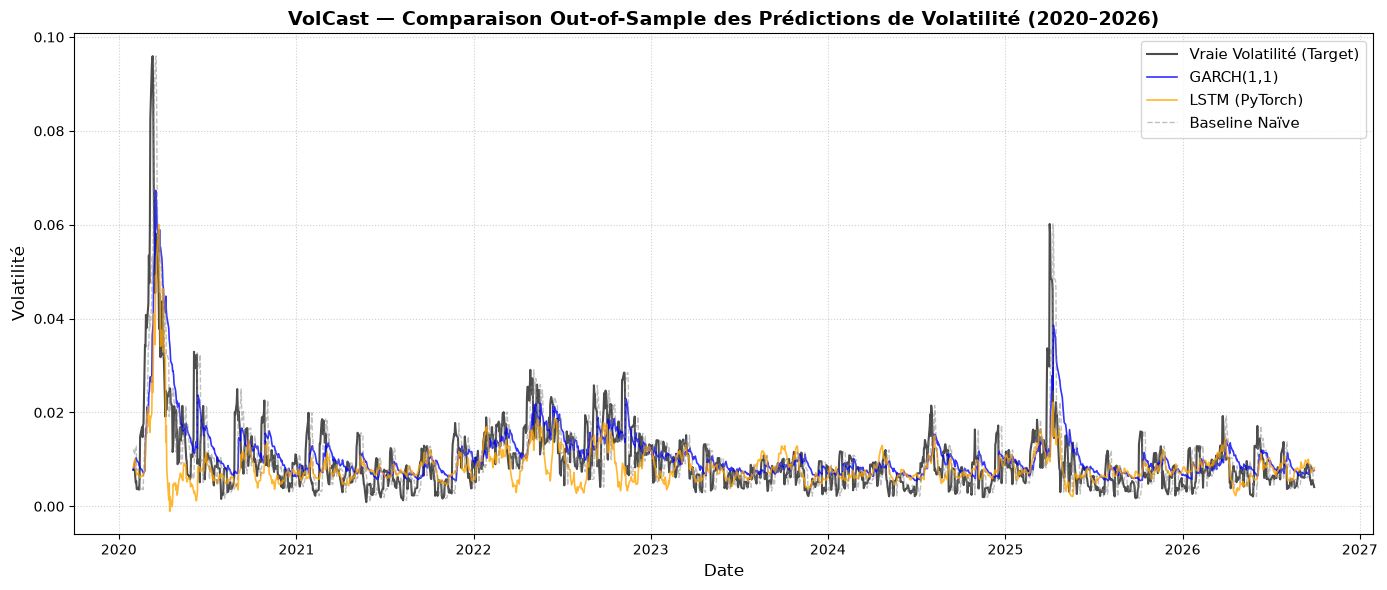

In [21]:
# Alignement des dates pour le jeu de test
test_dates = df_clean.index[-len(y_true):]

plt.figure(figsize=(14, 6))

# Plot des courbes
plt.plot(test_dates, y_true, label="Vraie Volatilité (Target)", color="black", alpha=0.7, linewidth=1.5)
plt.plot(test_dates, y_pred_garch, label="GARCH(1,1)", color="blue", alpha=0.8, linewidth=1.2)
plt.plot(test_dates, y_pred_lstm, label="LSTM (PyTorch)", color="orange", alpha=0.8, linewidth=1.2)
plt.plot(test_dates, y_pred_naive, label="Baseline Naïve", color="gray", linestyle="--", alpha=0.5, linewidth=1)

plt.title("VolCast — Comparaison Out-of-Sample des Prédictions de Volatilité (2020–2026)", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Volatilité", fontsize=12)
plt.legend(loc="upper right", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()